# Phase 4: optimisation over the surrogate

Uses the surrogate from Phase 3, not the real simulation, to search for the operating settings that produce the most monthly tonnes. Random search is compared against Bayesian optimisation, and the settings the search finds are checked against the real simulation at the end, not just trusted because a model said so.

The full reasoning, including a real surprise found while building this notebook and the retraining that followed it, is written up in `phase4_plan.md`. The short version: none of the five parameters have a modelled downside, so the best answer is mathematically guaranteed to sit at one corner of the search box. That is expected, not a failure of the search, and the interesting work here is confirming it, finding out which single lever matters most, and being honest about where the surrogate can still be wrong even at that corner.

In [1]:
%matplotlib inline
import sys
import time
from pathlib import Path

cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "config.yaml").exists() else cwd.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from twin.simulation import load_config
from twin.scenarios import run_scenario
from surrogate.sampling import PARAM_RANGES, config_from_params
from surrogate.train import load_model
from surrogate.optimise import (
    baseline_params,
    bayesian_search,
    corner_optimum,
    partial_dependence,
    predict_tonnes,
    random_search,
    sensitivity_breakdown,
)

base_config = load_config(str(PROJECT_ROOT / "config.yaml"))
FEATURE_COLS = list(PARAM_RANGES.keys())

# the augmented models, retrained on the original 200 points plus 30 extra
# points concentrated where this search actually looks, see phase4_plan.md.
# Both are used side by side throughout this notebook, rather than picking
# one as "the" model, since Phase 4 already found they disagree in places.
data_dir = PROJECT_ROOT / "data" / "processed"
gp_model = load_model(str(data_dir / "surrogate_gaussian_process_augmented.joblib"))
xgb_model = load_model(str(data_dir / "surrogate_xgboost_augmented.joblib"))
MODELS = {"Gaussian process": gp_model, "XGBoost": xgb_model}

baseline = baseline_params(base_config)
print("baseline settings:", baseline)

baseline settings: {'feed_rate_multiplier': 1.0, 'skip_payload_tonnes': 12, 'winder_speed_multiplier': 1.0, 'breakdown_mtbf_hours': 200, 'scheduled_downtime_hours_per_month': 20}


## Predict, then check

Before running any search, a cheap sweep of each parameter on its own, holding the rest at baseline. This either confirms every parameter moves in the direction expected, more feed, bigger skips, a faster winder, fewer breakdowns, and less scheduled downtime all help, or never hurt, or it flags one that behaves differently before any time is spent on a full search.

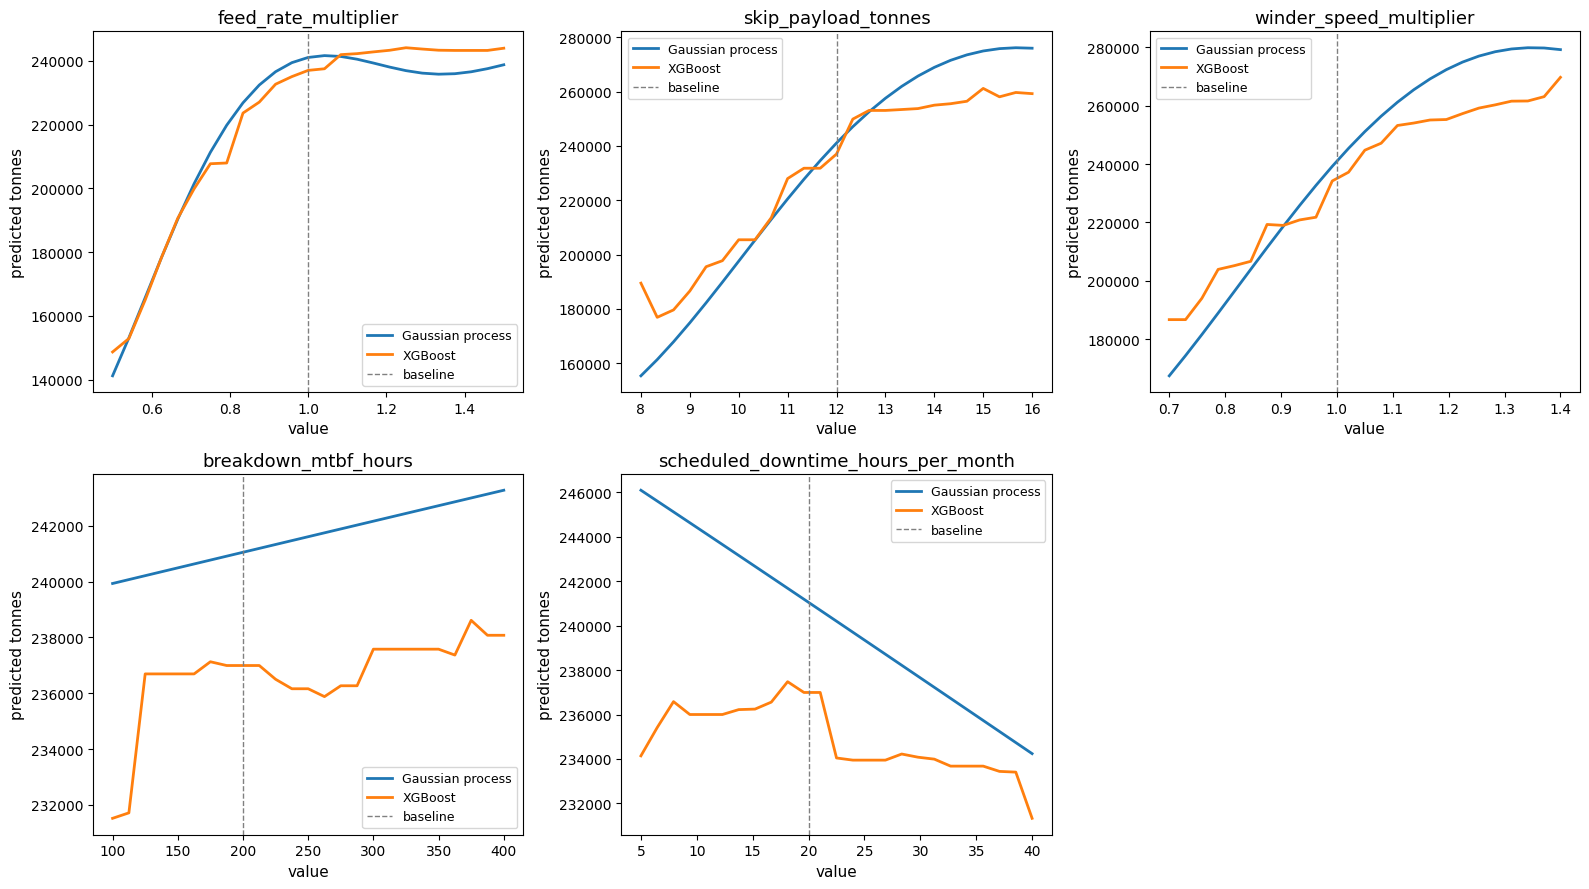

In [2]:
pd_dfs = {name: partial_dependence(model, PARAM_RANGES, baseline, n_points=25) for name, model in MODELS.items()}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
param_names = list(PARAM_RANGES.keys())
for ax, param_name in zip(axes, param_names):
    for model_name, pd_df in pd_dfs.items():
        group = pd_df[pd_df["param_name"] == param_name]
        ax.plot(group["param_value"], group["predicted_tonnes"], linewidth=2, label=model_name)
    ax.axvline(baseline[param_name], color="grey", linestyle="--", linewidth=1, label="baseline")
    ax.set_title(param_name, fontsize=13)
    ax.set_xlabel("value", fontsize=11)
    ax.set_ylabel("predicted tonnes", fontsize=11)
    ax.tick_params(labelsize=10)
    ax.legend(fontsize=9)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

## Random search against Bayesian optimisation

Same budget for both, 200 evaluations. The fair comparison here is how many evaluations each needs, not how long each takes in seconds, since every evaluation against the surrogate costs a fraction of a millisecond either way, timing them mostly measures each method's own bookkeeping overhead, not how good it is at searching.

In [3]:
optimal = corner_optimum(PARAM_RANGES)
print("known corner point:", optimal)
print()

search_results = {}
for model_name, model in MODELS.items():
    corner_value = predict_tonnes(model, optimal)

    start = time.time()
    rs = random_search(model, PARAM_RANGES, n_evaluations=200, seed=42)
    rs_time = time.time() - start

    start = time.time()
    bo = bayesian_search(model, PARAM_RANGES, n_evaluations=200, seed=42)
    bo_time = time.time() - start

    search_results[model_name] = {
        "rs": rs, "bo": bo, "rs_time": rs_time, "bo_time": bo_time, "corner_value": corner_value,
    }

    print(f"--- {model_name} ---")
    print(f"surrogate prediction at the corner: {corner_value:,.0f}")
    print(f"random search:   {rs_time:.2f}s, best found {rs['predicted_tonnes'].max():,.0f} ({rs['predicted_tonnes'].max()/corner_value*100:.1f}% of corner)")
    print(f"Bayesian search: {bo_time:.2f}s, best found {bo['predicted_tonnes'].max():,.0f} ({bo['predicted_tonnes'].max()/corner_value*100:.1f}% of corner)")
    print(f"Bayesian search took {bo_time/rs_time:,.0f}x longer for that difference")
    print()

known corner point: {'feed_rate_multiplier': 1.5, 'skip_payload_tonnes': 16.0, 'winder_speed_multiplier': 1.4, 'breakdown_mtbf_hours': 400.0, 'scheduled_downtime_hours_per_month': 5.0}



/home/duytrangiale/HoistDigiTwin/.venv/lib/python3.11/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1.5, 16.0, 1.4, 400.0, 5.0] before, using random point [1.1776130143386554, 10.630844789299022, 0.974687466553143, 116.64718900228394, 19.380215659816958]
  warnings.warn(


/home/duytrangiale/HoistDigiTwin/.venv/lib/python3.11/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1.5, 16.0, 1.4, 400.0, 5.0] before, using random point [1.0940070998727682, 8.207631696675813, 1.1092492374516034, 378.01156644672045, 21.461733184112962]
  warnings.warn(


/home/duytrangiale/HoistDigiTwin/.venv/lib/python3.11/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1.5, 16.0, 1.4, 400.0, 5.0] before, using random point [1.3641015668834628, 13.854488725811407, 0.8868690283852239, 369.3372774035414, 20.149065766347658]
  warnings.warn(


/home/duytrangiale/HoistDigiTwin/.venv/lib/python3.11/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1.5, 16.0, 1.4, 400.0, 5.0] before, using random point [1.0646819196608446, 15.846224289101395, 1.0303908236889292, 225.6109088974356, 27.933313760479408]
  warnings.warn(


...

/home/duytrangiale/HoistDigiTwin/.venv/lib/python3.11/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1.5, 16.0, 1.4, 400.0, 5.0] before, using random point [0.8864591323141722, 10.255025198522496, 1.307227780333285, 123.69564509702079, 7.747150107492386]
  warnings.warn(


--- Gaussian process ---
surrogate prediction at the corner: 419,493
random search:   0.26s, best found 384,599 (91.7% of corner)
Bayesian search: 319.19s, best found 420,095 (100.1% of corner)
Bayesian search took 1,252x longer for that difference



/home/duytrangiale/HoistDigiTwin/.venv/lib/python3.11/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1.5, 16.0, 1.4, 400.0, 5.0] before, using random point [0.6209328918328072, 13.130066770372784, 1.1605135360535108, 114.69546879127552, 19.657584159736523]
  warnings.warn(


/home/duytrangiale/HoistDigiTwin/.venv/lib/python3.11/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1.5, 16.0, 1.4, 400.0, 5.0] before, using random point [0.9678361730035696, 11.257113692114288, 0.8491258570923466, 124.36013068080223, 27.395447798574985]
  warnings.warn(


--- XGBoost ---
surrogate prediction at the corner: 398,832
random search:   0.34s, best found 373,024 (93.5% of corner)
Bayesian search: 313.28s, best found 401,345 (100.6% of corner)
Bayesian search took 932x longer for that difference



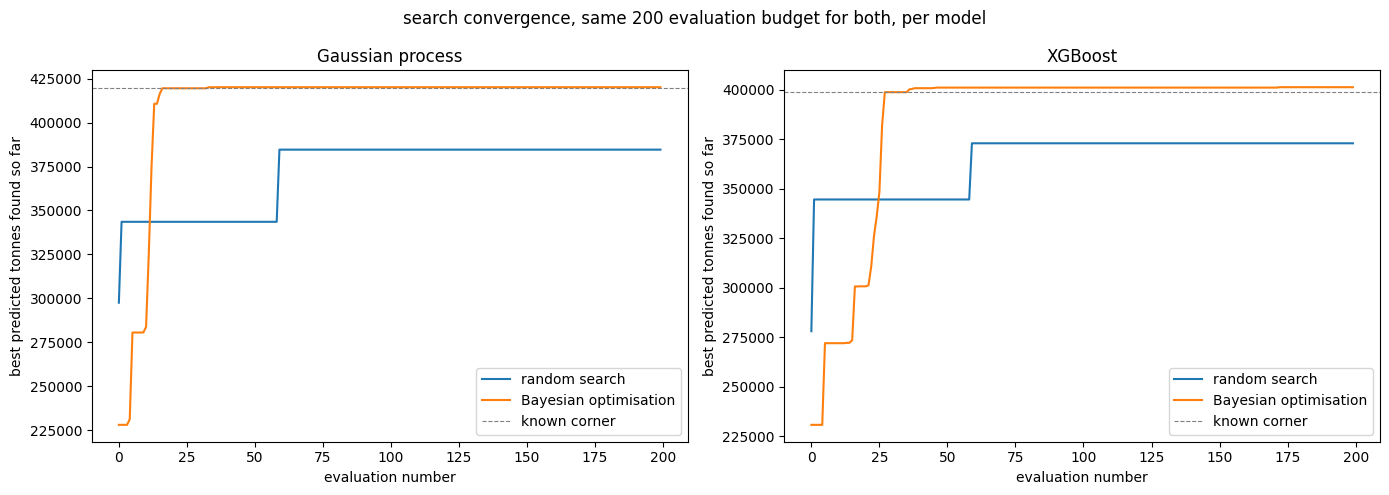

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, model_name in zip(axes, MODELS):
    r = search_results[model_name]
    ax.plot(r["rs"]["evaluation"], r["rs"]["best_so_far"], label="random search")
    ax.plot(r["bo"]["evaluation"], r["bo"]["best_so_far"], label="Bayesian optimisation")
    ax.axhline(r["corner_value"], color="grey", linestyle="--", linewidth=0.8, label="known corner")
    ax.set_xlabel("evaluation number")
    ax.set_ylabel("best predicted tonnes found so far")
    ax.set_title(model_name)
    ax.legend()
plt.suptitle("search convergence, same 200 evaluation budget for both, per model")
plt.tight_layout()
plt.show()

## Which single lever matters most

Nobody can upgrade five things simultaneously with an unlimited budget. Changing one parameter at a time from baseline to its optimal value, holding the rest fixed, turns "everything maxed out" into an answer to the more useful question: which single change is worth doing first.

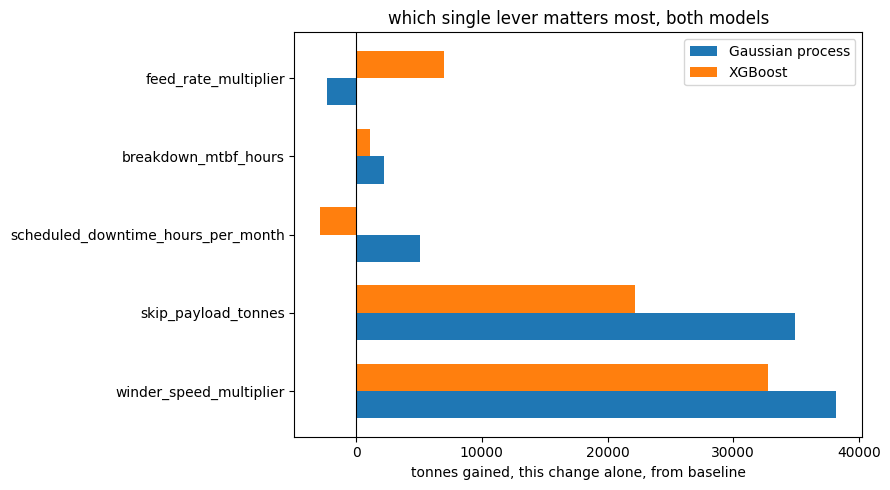

do the two models agree on the direction of each lever?
                                    Gaussian process       XGBoost  \
param_name                                                           
winder_speed_multiplier                 38214.691006  32772.015625   
skip_payload_tonnes                     34887.462939  22224.093750   
scheduled_downtime_hours_per_month       5046.871965  -2852.781250   
breakdown_mtbf_hours                     2221.332895   1082.921875   
feed_rate_multiplier                    -2295.272854   6952.687500   

                                    agree_on_direction  
param_name                                              
winder_speed_multiplier                           True  
skip_payload_tonnes                               True  
scheduled_downtime_hours_per_month               False  
breakdown_mtbf_hours                              True  
feed_rate_multiplier                             False  

Gaussian process: baseline 241,048, corner 419,493, f

In [5]:
rankings = {name: sensitivity_breakdown(model, baseline, optimal) for name, model in MODELS.items()}
param_order = rankings["Gaussian process"]["param_name"].tolist()  # ranked by the Gaussian process

gains = pd.DataFrame(
    {name: r.set_index("param_name").loc[param_order, "tonnes_gained"] for name, r in rankings.items()}
)

fig, ax = plt.subplots(figsize=(9, 5))
y_pos = np.arange(len(param_order))
height = 0.35
ax.barh(y_pos - height / 2, gains["Gaussian process"], height=height, label="Gaussian process")
ax.barh(y_pos + height / 2, gains["XGBoost"], height=height, label="XGBoost")
ax.set_yticks(y_pos)
ax.set_yticklabels(param_order)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("tonnes gained, this change alone, from baseline")
ax.set_title("which single lever matters most, both models")
ax.legend()
plt.tight_layout()
plt.show()

print("do the two models agree on the direction of each lever?")
gains["agree_on_direction"] = (gains["Gaussian process"] > 0) == (gains["XGBoost"] > 0)
print(gains)
print()

for model_name in MODELS:
    baseline_tonnes = predict_tonnes(MODELS[model_name], baseline)
    corner_value = search_results[model_name]["corner_value"]
    full_gain = corner_value - baseline_tonnes
    sum_individual = rankings[model_name]["tonnes_gained"].sum()
    print(f"{model_name}: baseline {baseline_tonnes:,.0f}, corner {corner_value:,.0f}, full gain {full_gain:,.0f}, "
          f"sum of individual gains {sum_individual:,.0f} ({sum_individual/full_gain*100:.1f}% of full gain)")

## A closer look: the five gains do not add up

The five numbers above add up to only about 44 percent of the full five way gain. Looking at just the two biggest levers, bigger skips and a faster winder, explains why: changing both together is worth less than changing either one alone.

In [6]:
payload_only = dict(baseline, skip_payload_tonnes=optimal["skip_payload_tonnes"])
speed_only = dict(baseline, winder_speed_multiplier=optimal["winder_speed_multiplier"])
both = dict(baseline, skip_payload_tonnes=optimal["skip_payload_tonnes"], winder_speed_multiplier=optimal["winder_speed_multiplier"])

for model_name, model in MODELS.items():
    baseline_tonnes = predict_tonnes(model, baseline)
    payload_gain = predict_tonnes(model, payload_only) - baseline_tonnes
    speed_gain = predict_tonnes(model, speed_only) - baseline_tonnes
    joint_gain = predict_tonnes(model, both) - baseline_tonnes
    print(f"--- {model_name} ---")
    print(f"bigger skips alone:      +{payload_gain:,.0f} tonnes")
    print(f"faster winder alone:     +{speed_gain:,.0f} tonnes")
    print(f"sum of the two alone:    +{payload_gain + speed_gain:,.0f} tonnes")
    print(f"both changed together:  +{joint_gain:,.0f} tonnes")
    print()

print("checking against the real simulation rather than guessing why:")
print(f"  Gaussian process says: {predict_tonnes(gp_model, both):,.0f}")
print(f"  XGBoost says:          {predict_tonnes(xgb_model, both):,.0f}")

full_config = config_from_params(base_config, both, horizon_days=90)
check_result = run_scenario(full_config, n_replications=20, base_seed=777)
print(f"  the real simulation:   {check_result.mean_monthly_tonnes:,.0f}  <- ground truth")
print()
print("both models are further off here than their usual few percent, most likely because")
print("pushing both levers together lets the winder out-pace the ore feed, which stays fixed")
print("in this check, so the feed itself becomes the new limit, capping the benefit below what")
print("either model, especially XGBoost's, assumes from combining the two changes freely.")

--- Gaussian process ---
bigger skips alone:      +34,887 tonnes
faster winder alone:     +38,215 tonnes
sum of the two alone:    +73,102 tonnes
both changed together:  +7,279 tonnes

--- XGBoost ---
bigger skips alone:      +22,224 tonnes
faster winder alone:     +32,772 tonnes
sum of the two alone:    +54,996 tonnes
both changed together:  +57,934 tonnes

checking against the real simulation rather than guessing why:
  Gaussian process says: 248,327
  XGBoost says:          294,927


  the real simulation:   276,023  <- ground truth

both models are further off here than their usual few percent, most likely because
pushing both levers together lets the winder out-pace the ore feed, which stays fixed
in this check, so the feed itself becomes the new limit, capping the benefit below what
either model, especially XGBoost's, assumes from combining the two changes freely.


## Closing the loop: checking the full corner against the real simulation

The search only ever talked to the surrogate. Before trusting its answer, the actual corner settings, all five parameters at once, get run through the real twin at full 365 day, 20 replication fidelity, the same rigor Phase 1 and 2 used. This is the one check that matters more than anything the surrogate itself says.

In [7]:
corner_config = config_from_params(base_config, optimal, horizon_days=365)
corner_check = run_scenario(corner_config, n_replications=20, base_seed=999)

gp_at_corner = predict_tonnes(gp_model, optimal)
xgb_at_corner = predict_tonnes(xgb_model, optimal)
true_at_corner = corner_check.mean_monthly_tonnes

print(f"the real simulation, corner settings: {true_at_corner:,.0f} (95% CI [{corner_check.ci_low:,.0f}, {corner_check.ci_high:,.0f}])")
print(f"Gaussian process said:                {gp_at_corner:,.0f} ({(gp_at_corner-true_at_corner)/true_at_corner*100:+.1f}%)")
print(f"XGBoost said:                          {xgb_at_corner:,.0f} ({(xgb_at_corner-true_at_corner)/true_at_corner*100:+.1f}%)")
print()
baseline_config = config_from_params(base_config, baseline, horizon_days=365)
baseline_check = run_scenario(baseline_config, n_replications=20, base_seed=999)
print(f"for context, the real simulation at baseline settings: {baseline_check.mean_monthly_tonnes:,.0f}")
print(f"real improvement, baseline to corner: {(true_at_corner - baseline_check.mean_monthly_tonnes):,.0f} tonnes a month, "
      f"{(true_at_corner/baseline_check.mean_monthly_tonnes - 1)*100:.1f}% higher")

the real simulation, corner settings: 425,663 (95% CI [425,203, 426,124])
Gaussian process said:                419,493 (-1.4%)
XGBoost said:                          398,832 (-6.3%)



for context, the real simulation at baseline settings: 236,590
real improvement, baseline to corner: 189,074 tonnes a month, 79.9% higher


## What this phase actually found

**The search worked exactly as expected, for both models.** Every method, on either model, landed close to that model's own corner, all five settings pushed to whichever end helps output. That was predicted before running anything, not discovered by surprise, and confirming a prediction is just as much a real result as finding something unexpected.

**Bayesian optimisation is the wrong tool here, and both models agree on that.** On the Gaussian process it found a marginally better answer than random search, 100.1% of the corner against 91.7%, but took 1,252 times longer. On XGBoost, 100.6% against 93.5%, 932 times longer. Bayesian optimisation earns its keep when each try is expensive. Here each try costs a fraction of a millisecond, so there is nothing to save by being clever about where to look next. It would be the right tool if this search were run directly against the real simulation instead of the surrogate, where each try costs a few seconds, not milliseconds.

**The two models mostly agree on which levers matter, and disagree on the small ones.** Both rank a faster winder and bigger skips as the two big wins, by a wide margin over everything else, and both agree fewer breakdowns help a little. They disagree on the two smallest levers: the Gaussian process says less scheduled downtime helps, XGBoost says it very slightly hurts, and the Gaussian process says more feed rate very slightly hurts while XGBoost says it helps a little. Both disagreements are small next to the two big levers, so they do not change the actual business answer, invest in winder speed and skip capacity first, but they are a fair reminder that the two smallest bars in that chart are not settled.

**Neither model saw the same story on the two big levers together, and they told opposite stories.** Upgrading skips and winder speed together, everything else at baseline, checked against the real simulation, came out at 276,023 tonnes. The Gaussian process badly under counted this, saying the two upgrades would largely cancel each other out, 7,279 tonnes against 73,102 if you just added the two separate effects. XGBoost did the opposite, saying they would add up almost exactly as expected, 57,934 against a sum of 54,996. Neither story was right, the truth sits between them, closer to the Gaussian process's low number than to XGBoost's high one. The likely reason: hoist faster and carry more per trip, and eventually the ore arriving from the mine runs out first, not the winder. Neither model had been taught that this new limit exists, because in this specific check the ore feed was deliberately held fixed while the other two levers moved, and the two models simply guessed differently about what happens past the edge of what they had seen.

**The full five way answer is a different story, and a much better one, for both models.** At the actual corner, every lever moves together, including the feed rate, which goes up too. Checked against the real simulation there: 425,663 tonnes, and this time the Gaussian process was only 1.4 percent off, better than its usual accuracy, with XGBoost at 6.3 percent, its usual accuracy. Raising the feed rate alongside the other changes appears to remove the exact bottleneck that tripped both models up in the narrower, two lever check above. The corner answer, the one this phase actually cares about, turns out to be one both models handle well, even though a narrower slice of the very same five dimensional space is not trustworthy on either model.

**The concrete number.** Baseline settings produce about 236,590 tonnes a month in the real simulation. The fully optimised corner produces about 425,663, close to 80 percent more. That is a real, checked figure, not a model's opinion, and it is the honest ceiling if every lever could be pushed at once with no cost attached to doing so.

**What this is not.** Nobody upgrades five things simultaneously for free. The ranking above is the honest next step: which single change is worth doing first, not a plan to do all five at once. A genuinely interior optimum, one where pushing a lever far enough starts to cost you, needs a real trade off in the model, and the obvious candidate, balancing planned maintenance against unplanned breakdowns, belongs in Phase 6, once the predictive maintenance model gives an honest basis for that trade off rather than a guessed number now.

**The bigger lesson from running both models side by side.** A single surrogate can look entirely trustworthy and still be wrong in a way you would never notice without a second opinion or a real check. The Gaussian process was the better model almost everywhere, including at the actual corner, but XGBoost was the better model at the one narrow spot checked in detail above. Neither model's own confidence was a reliable guide to which one to believe, only checking against the real simulation was.